In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [6]:
path = 'C:/Users/WoojaeYang/Desktop/DCR/'

surv500 = pd.read_csv(f'{path}data/survival_500.csv')
surv500.head(20)

,Patient_ID,Age,Gender,Diagnosis_Date,Treatment_Type,Comorbidities,Event,Survival_Time,BMI,Blood_Pressure_Upper,Blood_Pressure_Lower,Cholesterol,Medication_Dose,Exercise_Level,Smoking_Status,Family_History_CVD
0,1,77,Female,2021-10-07,Chemotherapy,NaN,0,149,19.9,93,92,191,0.00,4,0,1
1,2,50,Male,2021-10-04,Chemotherapy,Asthma,0,145,18.7,153,80,197,0.00,3,1,0
2,3,63,Female,2022-07-19,Surgery,NaN,0,135,21.2,98,95,166,0.00,3,0,0
3,4,84,Female,2019-07-02,Radiation,NaN,0,133,28.1,150,110,136,0.00,3,0,1
4,5,61,Male,2025-02-07,Medication,NaN,0,146,21.9,160,60,269,79.07,1,1,1
5,6,60,Female,2024-01-16,Radiation,Diabetes,0,124,18.5,96,87,130,0.00,2,1,0
6,7,76,Female,2017-08-13,Medication,Heart Disease,1,92,22.8,164,69,202,41.75,4,0,0
7,8,51,Male,2024-01-07,Medication,Asthma,1,47,34.8,178,93,165,16.84,0,1,1
8,9,82,Male,2024-10-08,Surgery,NaN,0,170,22.6,154,61,232,0.00,4,0,1
9,10,62,Female,2022-10-01,Chemotherapy,Heart Disease,1,116,27.6,121,109,275,0.00,4,0,1


In [8]:
surv500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            500 non-null    int64  
 1   Age                   500 non-null    int64  
 2   Gender                500 non-null    object 
 3   Diagnosis_Date        500 non-null    object 
 4   Treatment_Type        500 non-null    object 
 5   Comorbidities         397 non-null    object 
 6   Event                 500 non-null    int64  
 7   Survival_Time         500 non-null    int64  
 8   BMI                   500 non-null    float64
 9   Blood_Pressure_Upper  500 non-null    int64  
 10  Blood_Pressure_Lower  500 non-null    int64  
 11  Cholesterol           500 non-null    int64  
 12  Medication_Dose       500 non-null    float64
 13  Exercise_Level        500 non-null    int64  
 14  Smoking_Status        500 non-null    int64  
 15  Family_History_CVD    5

# 1

## Kaplan-Meier Fit

In [61]:
# Kaplan-Meier Fitter 객체 생성
kmf_smoker = KaplanMeierFitter()
kmf_non_smoker = KaplanMeierFitter()

In [63]:
smoker_group = surv200[surv200["Smoking_Status"] == 1]  # 흡연자
non_smoker_group = surv200[surv200["Smoking_Status"] == 0]  # 비흡연자

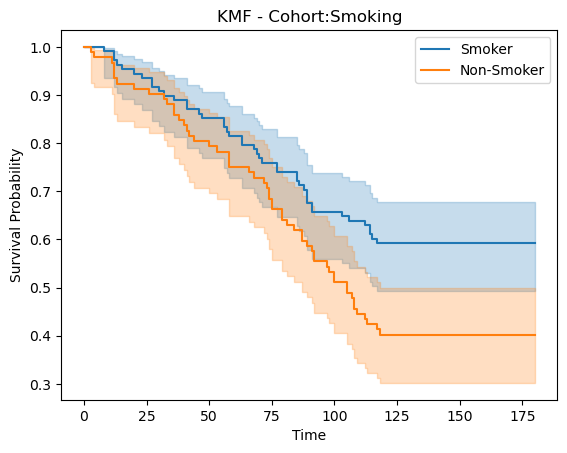

In [65]:
# 흡연자 생존 곡선
kmf_smoker.fit(smoker_group["Survival_Time"], event_observed=smoker_group["Event"], label="Smoker")
kmf_smoker.plot(ci_show=True)  # 신뢰구간 포함

# 비흡연자 생존 곡선
kmf_non_smoker.fit(non_smoker_group["Survival_Time"], event_observed=non_smoker_group["Event"], label="Non-Smoker")
kmf_non_smoker.plot(ci_show=True)  # 신뢰구간 포함

plt.title("KMF - Cohort:Smoking")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [104]:
kmf_non_smoker.survival_function_

,Non-Smoker
timeline,
0.0,1.000000
3.0,0.989130
4.0,0.978261
11.0,0.967391
12.0,0.934783
...,...
173.0,0.402174
175.0,0.402174
176.0,0.402174


In [67]:
# 생존 확률 테이블 생성
survival_prob_table = pd.DataFrame({
    "Time": kmf_non_smoker.survival_function_.index,
    "Non_Smoker": kmf_non_smoker.survival_function_.iloc[:, 0].values,
    "Smoker": kmf_smoker.survival_function_.reindex(kmf_non_smoker.survival_function_.index, method="nearest").iloc[:, 0].values
})
survival_prob_table

,Time,Non_Smoker,Smoker
0,0.0,1.000000,1.000000
1,3.0,0.989130,1.000000
2,4.0,0.978261,0.990741
3,11.0,0.967391,0.972222
4,12.0,0.934783,0.972222
...,...,...,...
66,173.0,0.402174,0.592593
67,175.0,0.402174,0.592593
68,176.0,0.402174,0.592593
69,179.0,0.402174,0.592593


## Log-Log

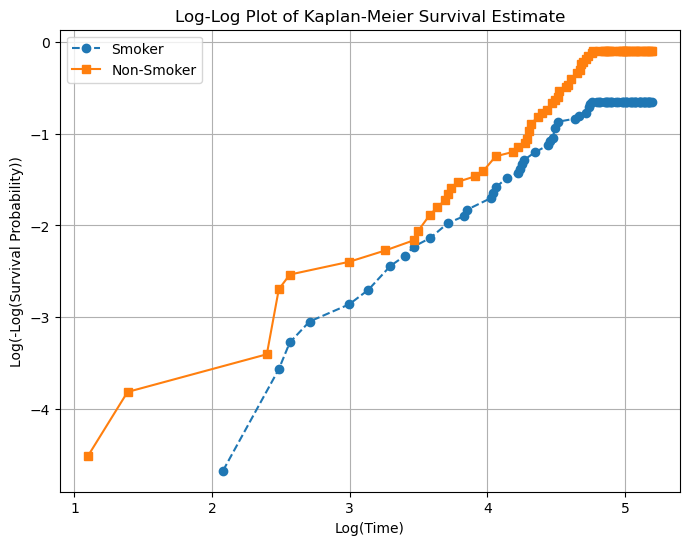

In [69]:
# 🔹 Log-Log Plot (로그-로그 변환)
plt.figure(figsize=(8, 6))

# 로그 변환한 생존 확률을 이용하여 Log-Log Plot 생성
plt.plot(np.log(kmf_smoker.survival_function_.index), 
         np.log(-np.log(kmf_smoker.survival_function_.iloc[:, 0])), label="Smoker", linestyle="--", marker="o")

plt.plot(np.log(kmf_non_smoker.survival_function_.index), 
         np.log(-np.log(kmf_non_smoker.survival_function_.iloc[:, 0])), label="Non-Smoker", linestyle="-", marker="s")

# 그래프 레이블 설정
plt.xlabel("Log(Time)")
plt.ylabel("Log(-Log(Survival Probability))")
plt.title("Log-Log Plot of Kaplan-Meier Survival Estimate")
plt.legend()
plt.grid(True)

plt.show()

In [73]:
# KM_estimate 값 가져오기
km_smoker = kmf_smoker.survival_function_.iloc[:,0].copy()
km_non_smoker = kmf_non_smoker.survival_function_.iloc[:,0].copy()

# KM_estimate 값이 0이 되면 로그 연산 불가능하므로 NaN 처리
km_smoker[km_smoker == 0] = np.nan
km_non_smoker[km_non_smoker == 0] = np.nan

# Log-Log 변환 테이블 생성
smoker_log_tbl = pd.DataFrame({
    "Time": kmf_smoker.survival_function_.index,
    "Over_BMI": np.log(-np.log(km_smoker)).values,
    "Under_BMI": np.log(-np.log(km_non_smoker)).reindex(kmf_smoker.survival_function_.index, method="nearest").values
})

smoker_log_tbl.head(10)

,Time,Over_BMI,Under_BMI
0,0.0,-inf,-inf
1,8.0,-4.677484,-3.406646
2,12.0,-3.569467,-2.696498
3,13.0,-3.277026,-2.536571
4,15.0,-3.049086,-2.536571
5,20.0,-2.861929,-2.397206
6,23.0,-2.702903,-2.273532
7,27.0,-2.441716,-2.273532
8,30.0,-2.331358,-2.162220
9,32.0,-2.231007,-2.162220


# 2

## Kaplan-Meier

In [22]:
# Kaplan-Meier Fitter 객체 생성
kmf_over_weight = KaplanMeierFitter()
kmf_good_weight = KaplanMeierFitter()

In [24]:
surv200['BMI'].describe()

count    200.000000
mean      26.804000
std        4.891268
min       18.700000
25%       22.600000
50%       26.450000
75%       31.325000
max       35.000000
Name: BMI, dtype: float64

In [26]:
df_over_weight = surv200[surv200['BMI'] > 25]
df_good_weight = surv200[surv200['BMI'] <= 25]

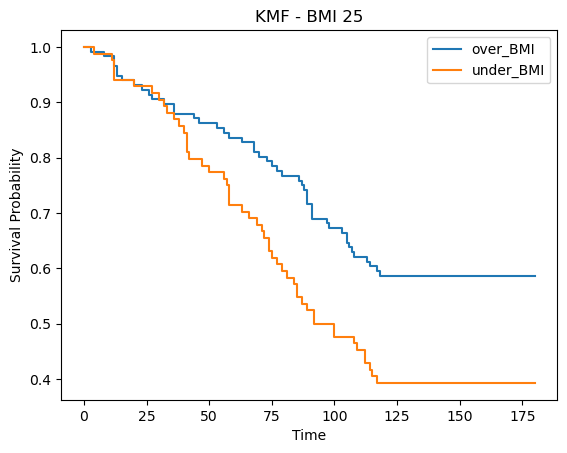

In [32]:
kmf_over_weight.fit(df_over_weight["Survival_Time"], event_observed=df_over_weight["Event"], label="over_BMI")
kmf_over_weight.plot(ci_show=False)  # 신뢰구간 제외

kmf_good_weight.fit(df_good_weight["Survival_Time"], event_observed=df_good_weight["Event"], label="under_BMI")
kmf_good_weight.plot(ci_show=False)  # 신뢰구간 제외

plt.title("KMF - BMI 25")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [40]:
# 생존 확률 테이블 생성
bmi_prob_table = pd.DataFrame({
    "Time": kmf_over_weight.survival_function_.index,
    "Non_Smoker": kmf_over_weight.survival_function_.iloc[:, 0].values,
    "Smoker": kmf_good_weight.survival_function_.reindex(kmf_over_weight.survival_function_.index, method="nearest").iloc[:, 0].values
})
bmi_prob_table

,Time,Non_Smoker,Smoker
0,0.0,1.000000,1.000000
1,3.0,0.991379,0.988095
2,8.0,0.982759,0.976190
3,12.0,0.965517,0.940476
4,13.0,0.948276,0.940476
...,...,...,...
75,176.0,0.586207,0.392857
76,177.0,0.586207,0.392857
77,178.0,0.586207,0.392857
78,179.0,0.586207,0.392857


## Log-Log

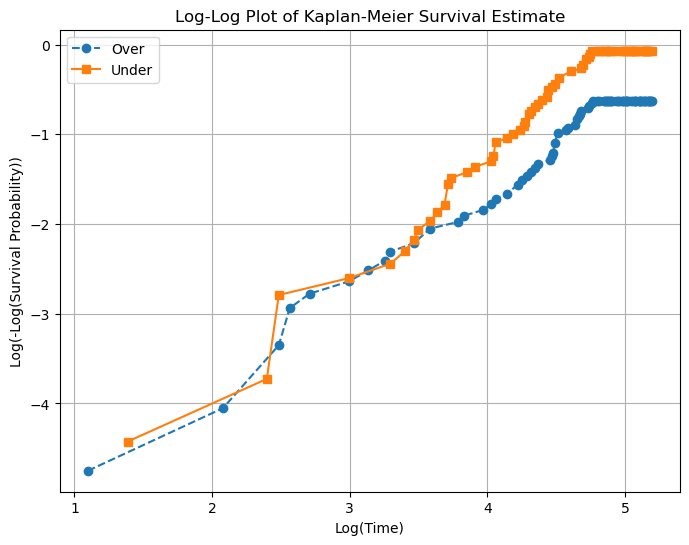

In [96]:
# 🔹 Log-Log Plot (로그-로그 변환)
plt.figure(figsize=(8, 6))

# 로그 변환한 생존 확률을 이용하여 Log-Log Plot 생성
plt.plot(np.log(kmf_over_weight.survival_function_.index), 
         np.log(-np.log(kmf_over_weight.survival_function_.iloc[:, 0])), label="Over", linestyle="--", marker="o")

plt.plot(np.log(kmf_good_weight.survival_function_.index), 
         np.log(-np.log(kmf_good_weight.survival_function_.iloc[:, 0])), label="Under", linestyle="-", marker="s")

# 그래프 레이블 설정
plt.xlabel("Log(Time)")
plt.ylabel("Log(-Log(Survival Probability))")
plt.title("Log-Log Plot of Kaplan-Meier Survival Estimate")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
# KM_estimate 값 가져오기
km_over_bmi = kmf_over_weight.survival_function_.iloc[:,0].copy()
km_under_bmi = kmf_good_weight.survival_function_.iloc[:,0].copy()

# KM_estimate 값이 0이 되면 로그 연산 불가능하므로 NaN 처리
km_over_bmi[km_over_bmi == 0] = np.nan
km_under_bmi[km_under_bmi == 0] = np.nan

# Log-Log 변환 테이블 생성
bmi_log_tbl = pd.DataFrame({
    "Time": kmf_over_weight.survival_function_.index,
    "Over_BMI": np.log(-np.log(km_over_bmi)).values,
    "Under_BMI": np.log(-np.log(km_under_bmi)).reindex(kmf_over_weight.survival_function_.index, method="nearest").values
})

bmi_log_tbl.head(10)

,Time,Over_BMI,Under_BMI
0,0.0,-inf,-inf
1,3.0,-4.749264,-4.424835
2,8.0,-4.051760,-3.725645
3,12.0,-3.349801,-2.790851
4,13.0,-2.935393,-2.790851
5,15.0,-2.776720,-2.790851
6,20.0,-2.638632,-2.602232
7,23.0,-2.516257,-2.602232
8,26.0,-2.406268,-2.441716
9,27.0,-2.306294,-2.441716


In [75]:
surv200['Treatment_Type'].unique()

array(['Surgery', 'Medication', 'Radiation', 'Chemotherapy'], dtype=object)

# 3

## Kaplan Meier

In [83]:
surv200_male = surv200[surv200['Gender'] == 'Male']
surv200_fem = surv200[surv200['Gender'] == 'Female']

In [89]:
# Kaplan-Meier Fitter 객체 생성
kmf_mal = KaplanMeierFitter()
kmf_fem = KaplanMeierFitter()

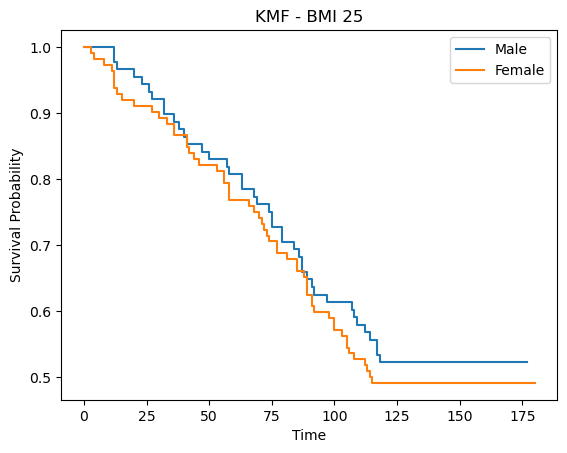

In [91]:
kmf_mal.fit(surv200_male["Survival_Time"], event_observed=surv200_male["Event"], label="Male")
kmf_mal.plot(ci_show=False)  # 신뢰구간 제외

kmf_fem.fit(surv200_fem["Survival_Time"], event_observed=surv200_fem["Event"], label="Female")
kmf_fem.plot(ci_show=False)  # 신뢰구간 제외

plt.title("KMF - BMI 25")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [106]:
kmf_mal.survival_function_

,Male
timeline,
0.0,1.000000
12.0,0.977273
13.0,0.965909
20.0,0.954545
23.0,0.943182
...,...
172.0,0.522727
173.0,0.522727
174.0,0.522727


In [110]:
# 생존 확률 테이블 생성
survival_prob_table_Gender = pd.DataFrame({
    "Time": kmf_mal.survival_function_.index,
    "Male": kmf_mal.survival_function_.iloc[:, 0].values,
    "Female": kmf_fem.survival_function_.reindex(kmf_mal.survival_function_.index, method="nearest").iloc[:, 0].values
})
survival_prob_table_Gender

,Time,Male,Female
0,0.0,1.000000,1.000000
1,12.0,0.977273,0.937500
2,13.0,0.965909,0.928571
3,20.0,0.954545,0.910714
4,23.0,0.943182,0.910714
...,...,...,...
61,172.0,0.522727,0.491071
62,173.0,0.522727,0.491071
63,174.0,0.522727,0.491071
64,176.0,0.522727,0.491071


## Log-Log

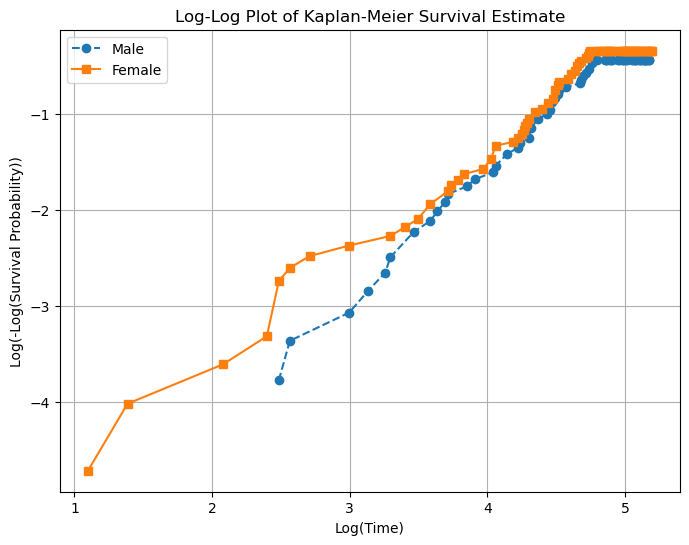

In [98]:
# 🔹 Log-Log Plot (로그-로그 변환)
plt.figure(figsize=(8, 6))

# 로그 변환한 생존 확률을 이용하여 Log-Log Plot 생성
plt.plot(np.log(kmf_mal.survival_function_.index), 
         np.log(-np.log(kmf_mal.survival_function_.iloc[:, 0])), label="Male", linestyle="--", marker="o")

plt.plot(np.log(kmf_fem.survival_function_.index), 
         np.log(-np.log(kmf_fem.survival_function_.iloc[:, 0])), label="Female", linestyle="-", marker="s")

# 그래프 레이블 설정
plt.xlabel("Log(Time)")
plt.ylabel("Log(-Log(Survival Probability))")
plt.title("Log-Log Plot of Kaplan-Meier Survival Estimate")
plt.legend()
plt.grid(True)

plt.show()

In [94]:
# KM_estimate 값 가져오기
km_mal = kmf_mal.survival_function_.iloc[:,0].copy()
km_fem = kmf_fem.survival_function_.iloc[:,0].copy()

# KM_estimate 값이 0이 되면 로그 연산 불가능하므로 NaN 처리
km_mal[km_mal == 0] = np.nan
km_fem[km_fem == 0] = np.nan

# Log-Log 변환 테이블 생성
bmi_log_tbl = pd.DataFrame({
    "Time": kmf_mal.survival_function_.index,
    "Male": np.log(-np.log(km_mal)).values,
    "Female": np.log(-np.log(km_fem)).reindex(kmf_mal.survival_function_.index, method="nearest").values
})

bmi_log_tbl.head(10)

,Time,Male,Female
0,0.0,-inf,-inf
1,12.0,-3.772717,-2.740493
2,13.0,-3.361432,-2.602232
3,20.0,-3.067873,-2.369515
4,23.0,-2.838793,-2.369515
5,26.0,-2.650476,-2.269360
6,27.0,-2.490269,-2.269360
7,32.0,-2.226653,-2.092494
8,36.0,-2.115044,-1.939416
9,38.0,-2.013419,-1.939416
